Mínimo global conocido se encuentra en $x = [0, 0, ..., 0]$ con un valor de $f(x) = 0$.La ecuación de la función es:$$f(\mathbf{x}) = A \cdot n + \sum_{i=1}^{n} \left[ x_i^2 - A \cdot \cos(2 \pi x_i) \right]$$

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Definición de la función de Rastrigin
def rastrigin(x, A=10):
    n = len(x)
    return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))

In [ ]:
def recocido_simulado(funcion_costo, bounds, max_iter, T_init, alpha, step_size):
    # solución aleatoria dentro de los límites
    dim = len(bounds)
    current_sol = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
    current_eval = funcion_costo(current_sol)
    
    # para guardar la mejor solución encontrada
    best_sol = np.copy(current_sol)
    best_eval = current_eval
    
    history = [current_eval] # para graficar
    T = T_init
    
    for i in range(max_iter):
        # Generar un vecino candidato sumando un paso aleatorio 
        candidate = current_sol + np.random.normal(0, step_size, size=dim)
        
        # Forzar a que el candidato se mantenga dentro de los límites de búsqueda
        for j in range(dim):
            candidate[j] = np.clip(candidate[j], bounds[j][0], bounds[j][1])
            
        # evaluar el candidato
        candidate_eval = funcion_costo(candidate)
        
        # guardar si es la mejor solución global jamás vista
        if candidate_eval < best_eval:
            best_sol, best_eval = np.copy(candidate), candidate_eval
            
        # calcular la diferencia de energía / costo
        diff = candidate_eval - current_eval
        
        # Criterio de aceptación
        if diff < 0:
            # ci es mejor, se acepta 
            current_sol, current_eval = candidate, candidate_eval
        else:
            # Si es peor, se acepta con una probabilidad que depende de la temperatura
            metropolis = np.exp(-diff / T)
            if np.random.rand() < metropolis:
                current_sol, current_eval = candidate, candidate_eval
                
        # se guarda el estado actual en el historial y enfriar la temperatura
        history.append(current_eval)
        T *= alpha
        
    return best_sol, best_eval, history

In [37]:
dimensiones = 2
limites = np.array([[-5.12, 5.12]] * dimensiones)

# Hiperparámetros del algoritmo
max_iteraciones = 2000
temperatura_inicial = 50.0
factor_enfriamiento = 0.99
tamaño_paso = 0.5

mejor_solucion, mejor_evaluacion, historial = recocido_simulado(
    funcion_costo=rastrigin,
    bounds=limites,
    max_iter=max_iteraciones,
    T_init=temperatura_inicial,
    alpha=factor_enfriamiento,
    step_size=tamaño_paso
)

print(f"Mejor posición encontrada: {mejor_solucion}")
print(f"Valor de la función en la mejor solución: {mejor_evaluacion:.6f}")

Mejor posición encontrada: [0.00800431 0.01200895]
Valor de la función en la mejor solución: 0.041306


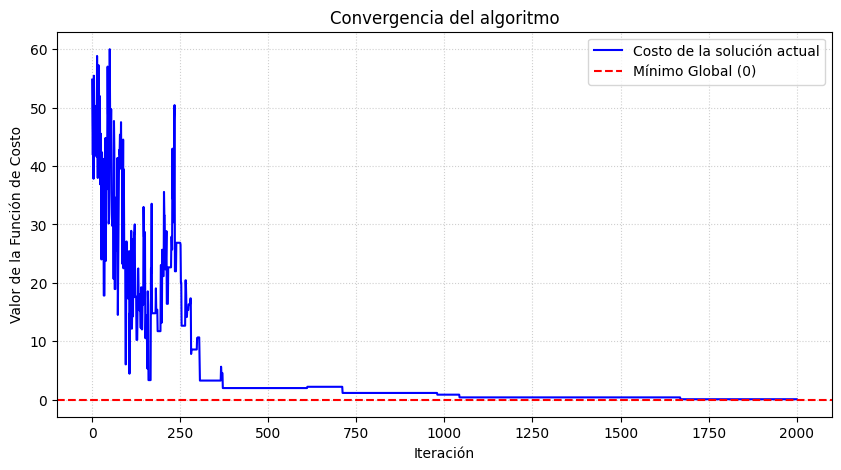

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(historial, color='blue', label='Costo de la solución actual')
plt.axhline(y=0, color='r', linestyle='--', label='Mínimo Global (0)')
plt.title('Convergencia del algoritmo')
plt.xlabel('Iteración')
plt.ylabel('Valor de la Función de Costo')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()